# Het Frenetstelsel voor een helix

Dit werkblad bestaat uit één grote opgave. We berekenen het Frenetstelsel gekoppeld aan een helix of schroeflijn en maken een animatie van dit stelsel dat meereist met de kromme. We gaan deze animatie als videobestand op de computer laten opslaan.

## Definiëren van de schroeflijn

Om te beginnen importeren we Sympy

In [15]:
import sympy as sp
from IPython.display import display

Vervolgens definiëren we korte namen voor de drie eenheidsvectoren in de ruimte.

In [16]:
bfi = sp.Matrix([1,0,0])
bfj = sp.Matrix([0,1,0])
bfk = sp.Matrix([0,0,1])

**Opdracht 1:** In volgend stuk code zijn al drie symbolen `a`, `b` en `s` gedefinieerd. Definieer nu een kolomvector `helix` die volgende kromme voorstelt:

$$
r(s)
=
a\cdot\cos\left(\frac{s}{\sqrt{a^2 + b^2}}\right)\cdot \vec{e_x}
+
a\cdot\sin\left(\frac{s}{\sqrt{a^2 + b^2}}\right)\cdot \vec{e_y}
+
\frac{bs}{\sqrt{a^2+b^2}}\cdot\vec{e_z}.
$$

Maak gebruik van de vectoren die hierboven al gedefinieerd staan.

In [17]:
a = sp.symbols('a', positive=True)
b = sp.symbols('b', positive=True)
s = sp.symbols('s', real=True)
# Los hieronder de opgave op
xr = a*sp.cos(s/(sp.sqrt(a**2 + b**2))) * bfi
yr = a*sp.sin(s/(sp.sqrt(a**2 + b**2))) * bfj
zr = b*s/(sp.sqrt(a**2 + b**2)) * bfk

helix = xr + yr + zr
display(helix)


Matrix([
[a*cos(s/sqrt(a**2 + b**2))],
[a*sin(s/sqrt(a**2 + b**2))],
[     b*s/sqrt(a**2 + b**2)]])

Controleer nu of de parametrisatie de booglengteparametrisatie is. Hiervoor doe je de volgende twee dingen:
 * Bereken de snelheidsvector `snelheidv` door m.b.v. `diff` de kromme af te leiden naar de parameter `s`.
 * Bereken de norm van de snelheidsvector en controleer of dit vereenvoudigt tot 1.

In [18]:
# Los hier de opgave op
snelheidv = sp.diff(helix, s)
snelheidv
normsnelheidv = sp.sqrt(snelheidv.dot(snelheidv))
normsnelheidv.simplify()


1

## Tekenen van de schroeflijn

Alvorens we de schroeflijn kunnen tekenen, moeten we eerst concrete waarden geven voor de parameters `a` en `b`. 

**Opdracht 2:** Gebruik de methode `.subs()` om een nieuwe variabele `helixSub` te definiëren waarbij je in `helix` de parameter `a` vervangt door 4 en de parameter `b` vervangt door 3.

In [19]:
# Los hier de opgave op
helixSub = helix.subs([(a, 4), (b, 3)])
helixSub

Matrix([
[4*cos(s/5)],
[4*sin(s/5)],
[     3*s/5]])

Nu gaan we over tot het tekenen van de schroeflijn. Eerst laden we Numpy in en de relevante plotfuncties voor 3D plots. Voor één keer laten we `%matplotlib notebook` weg uit de code. Nu krijg je voor iedere plot een apart venstertje. Dit lijkt onnodig maar uiteindelijk zal het handig blijken om de animatie stap voor stap op te bouwen.

In [20]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

Het tekenen van de helix gebeurt als volgt. Eerst bekijken we over welk domein de parameter zal lopen. Hier kiezen we voor het interval $[0,10\pi]$. We kiezen ervoor om in 100 punten van dit interval het bijhorend punt op de kromme te berekenen. De variabele `ss` bevat de 100 punten waarin we de functies berekenen. De drie variabelen eronder bevatten dan de relevante componenten van de punten op de kromme. Deze worden berekend via `lambdify`.

In [21]:
ss = np.linspace(0,10*np.pi, 100)
xmarks = sp.lambdify(s, helixSub[0], "numpy")(ss)
ymarks = sp.lambdify(s, helixSub[1], "numpy")(ss)
zmarks = sp.lambdify(s, helixSub[2], "numpy")(ss)

Tenslotte maken we de figuur aan en tekenen we de variabelen `xmarks`, `ymarks` en `zmarks`.

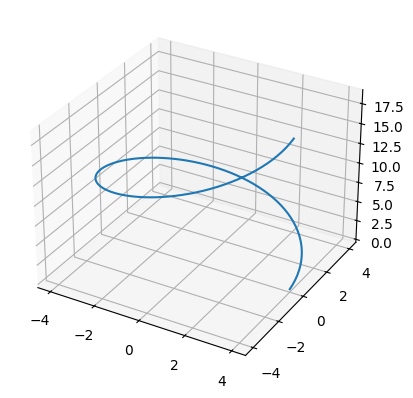

In [22]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(xmarks,ymarks,zmarks)

plt.show()

## Berekenen van het Frenetstelsel

We berekenen nu symbolisch het Frenetstelsel in ieder punt van de kromme. We beginnen met de vector $\hat{T}$. Deze is gedefinieerd als de raakvector aan de kromme van lengte $1$. 

**Opdracht 3a:** Bereken hieronder de snelheidsvector van `helixSub` en normeer deze om de variabele `hatT` te bekomen. Het kan handig zijn om de bekomen uitdrukkingen nog te vereenvoudigen.

In [25]:
# Los hier de opdracht op
hatT = snelheidv / normsnelheidv
hatT.simplify()
hatT

Matrix([
[-a*sin(s/sqrt(a**2 + b**2))/sqrt(a**2 + b**2)],
[ a*cos(s/sqrt(a**2 + b**2))/sqrt(a**2 + b**2)],
[                          b/sqrt(a**2 + b**2)]])

**Opdracht 3b:** De volgende vector is de vector $\hat{N}$. Bereken hiervoor de afgeleide van $\hat{T}$, normeer deze vector tot lengte 1 en steek dit in de variabele `hatN`.

In [26]:
# Los hier de opdracht op
hatN = sp.diff(hatT, s) / sp.sqrt(sp.diff(hatT, s).dot(sp.diff(hatT, s)))
hatN.simplify()
hatN

Matrix([
[-cos(s/sqrt(a**2 + b**2))],
[-sin(s/sqrt(a**2 + b**2))],
[                        0]])

**Opdracht 3c:** De derde vector van het Frenetstelsel is de binormaal $\hat{B}$. Deze is gedefinieerd als het kruisproduct $\hat{T}\times\hat{N}$. Bereken deze vector en steek deze in de variabele `hatB`. Moet je deze vector ook nog normeren?

In [27]:
# Los hier de opgave op
hatB = hatT.cross(hatN)
hatB

Matrix([
[                                                     b*sin(s/sqrt(a**2 + b**2))/sqrt(a**2 + b**2)],
[                                                    -b*cos(s/sqrt(a**2 + b**2))/sqrt(a**2 + b**2)],
[a*sin(s/sqrt(a**2 + b**2))**2/sqrt(a**2 + b**2) + a*cos(s/sqrt(a**2 + b**2))**2/sqrt(a**2 + b**2)]])

## Het maken van animaties

Vooraleer we het hele Frenetstelsel animeren, zullen we eerst iets makkelijker voorbeelden bekijken. Laten we beginnen met volgende sinusfunctie.
$$f(x) = \sin\left(\frac{2\pi}{p}x\right)$$
Hier staat de parameter $p$ voor de periode van $f$. We gaan nu de grafiek van $f$ animeren terwijl de parameter $p$ loopt van $1$ tot $2\pi$ en dit op het interval $[0, 6\pi]$. Om animaties te kunnen maken moet je eerst de animatiemogelijkheden van Matplotlib inladen. Dit doe je als volgt.

In [28]:
import matplotlib.animation as animation

We geven eerst de volledige code mee van de animatie. Voer deze eens uit om te kijken naar het eindresultaat. Daarna zullen we de code stap voor stap overlopen. Je kan deze code altijd gebruiken als eenvoudige referentie naar toekomstige animaties die je in elkaar wilt steken.

MovieWriter ffmpeg unavailable; using Pillow instead.


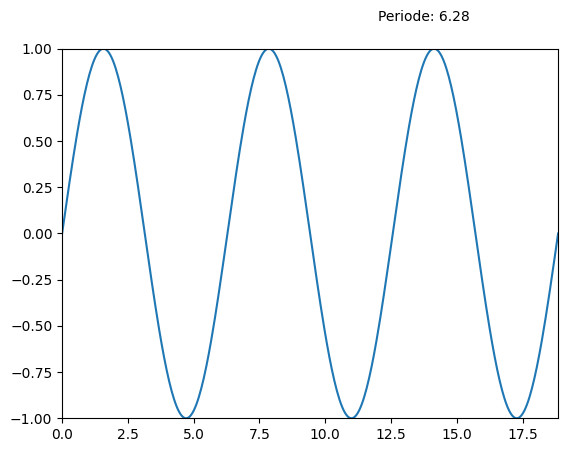

In [29]:
p = np.linspace(1, 2*np.pi, 100)
X = np.linspace(0, 6*np.pi, 400)

fig, ax = plt.subplots(1,1)
ax.set_xlim([0, 6*np.pi])
ax.set_ylim([-1, 1])

sinuskromme, = ax.plot([], [])
box = ax.text(12, 1.15, '')

def animate(i):
    Y = np.sin(2*X*np.pi/p[i])
    sinuskromme.set_data(X, Y)
    box.set_text('Periode: ' + str(np.round(p[i], 2))) # Rond de periode af op twee decimalen

anim = animation.FuncAnimation(fig, animate, frames=100, interval=50)
anim.save("sinus.gif")
plt.show()

De code begint met  volgende instructies.

``
p = np.linspace(1, 2*np.pi, 100)
X = np.linspace(0, 6*np.pi, 400)
``

Eerst maken we een Numpy-lijst aan van 100 waarden tussen $1$ en $2\pi$ om de verschillende waarden van $p$ voor te stellen. Ook maken we ook een lijst aan met de nodige $x$-waarden. Vervolgens zien we

``
fig, ax = plt.subplots(1,1)
ax.set_xlim([0, 6*np.pi])
ax.set_ylim([-1, 1])
``

Het idee is om voor alle 100 waarden uit de lijst van $p$ de grafiek van de sinuskromme te tekenen. Deze 100 grafieken plakken we achter elkaar om zo de animatie te verkrijgen. Eerst zetten we een plotvenster klaar met de juiste afmetingen. Nu maken we een initiële plot.

``
sinuskromme, = ax.plot([], [])
box = ax.text(12, 1.15, '')
``

Merk op dat we voorlopig nog geen data plotten en dat we de plotgegevens opslaan in een variabele `sinuskromme`. Let goed op de komma die na `sinuskromme` staat. Deze is nodig omdat `ax.plot()` een lijst met één object teruggeeft. Door de komma te gebruiken, kunnen we dit ene object opslaan in `sinuskromme` in plaats van de lijst met één object erin te steken. 

Ook maken we een klein tekstobject aan waarop we tijdens de animatie de periode van de sinuskromme aflezen. Dit doen we door aan `ax.text()` de coördinaten van het tekstobject mee te geven alsook de tekst die er moet verschijnen. Hier nemen we voorlopig geen tekst omdat deze toch continu zal veranderen doorheen de animatie.

``
def animate(i):
    Y = np.sin(2*X*np.pi/p[i])  
    sinuskromme.set_data(X, Y)  
    box.set_text('Periode: ' + str(np.round(p[i], 2))) 
``

Nu alles klaarstaat, kunnen we de animatie opstellen. Zoals eerder gezegd zal de animatie bestaan uit 100 beelden (omdat we 100 waarden voor $p$ gebruiken). De animatie bestaat er nu gewoon in te zeggen wat we moeten aanpassen bij ieder beeld. We kunnen nu in ieder beeld de lege plot `sinuskromme` aanpassen door de gewenste grafiek te tekenen. Dit doen we door gebruik te maken van `.set_data()`. Ook het tekstobject kunnen we aanpassen via `.set_text()`. Al deze instructies steken we in de functie `animate()`. Het argument `i` dat we meegeven aan `animate()` zegt ons welk beeld van de animatie we aan het bewerken zijn.

``
anim = animation.FuncAnimation(fig, animate, frames=100, interval=50)
anim.save("sinus.gif")
plt.show()
``

Tenslotte steken we de hele animatie in elkaar. Zoals je kan zien geven we vier argumenten mee aan de methode `.FuncAnimation()`. Eerst komt de figuur, dan de animatiefunctie, vervolgens het aantal frames en tenslotte hoeveel milliseconden er tussen twee frames zit. Daarna slaan we de animatie op in de lokale folder waar deze jupyter notebook ook opgeslagen is genaamd "sinus.gif."

**Opdracht 4:** Maak een animatie waarbij de cirkel $x(t) = a \cos t, \quad y(t) = a \sin t$ getekend wordt en waarbij de straal toeneemt van 0 tot 2. Het begin van de code is hieronder al gegeven.

MovieWriter ffmpeg unavailable; using Pillow instead.


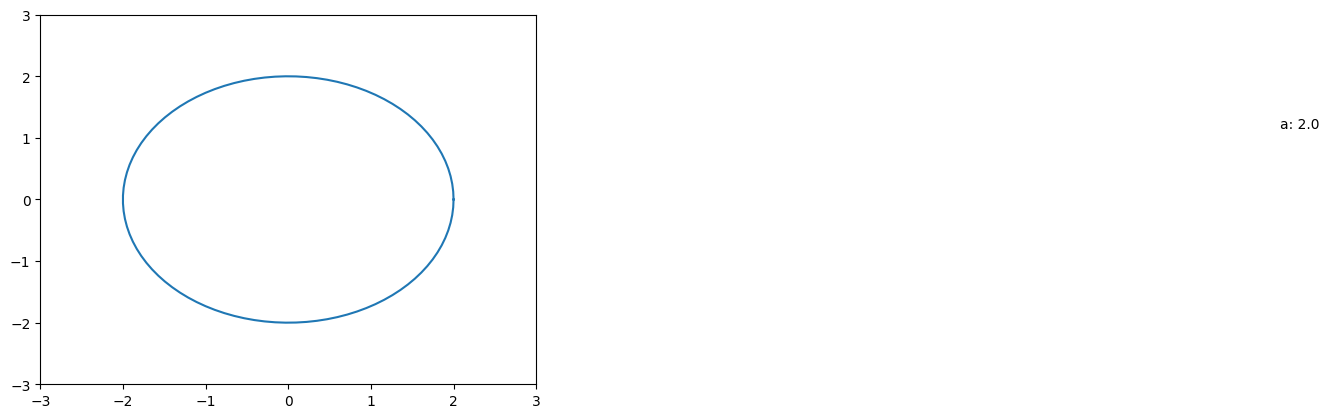

In [31]:
a = np.linspace(0, 2, 100) # Parameter a varieert tussen 0 en 2.
T = np.linspace(0, 2*np.pi, 100) # Voor iedere waarde van a moet de volledige cirkel getoond worden, dus T van 0 tot 2*pi.

fig, ax = plt.subplots(1,1)
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])

# Vul hieronder de code aan.
sinuskromme, = ax.plot([], [])
box = ax.text(12, 1.15, '')

def animate(i):
    X = a[i]*np.cos(T)
    Y = a[i]*np.sin(T)
    sinuskromme.set_data(X, Y)
    box.set_text('a: ' + str(np.round(a[i], 2))) # Rond de periode af op twee decimalen

anim = animation.FuncAnimation(fig, animate, frames=100, interval=50)
anim.save("cirkel.gif")
plt.show()

## Het geanimeerde Frenetstelsel: deel 1

Als inleiding op animaties in 3D gaan we eerst onze schroeflijn tekenen samen met een lijnstuk dat steeds vertrekt in de oorsprong en tijdens een animatie de kromme overloopt.

Onderstaande code tekent het lijnstuk dat loopt van $(0,0,0)$ naar $(4, 0, 0)$. In de functie `plot` steek je dan eerst de $x$-waarden ($4$ en $0$). Vervolgens de $y$-waarden ($0$ en $0$) en tenslotte de $z$-waarden (ook $0$ en $0$). Dit is de positievector voor waarde $s=0$ van de booglengteparameter.

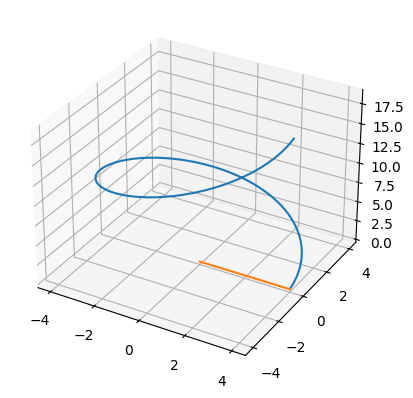

In [32]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(xmarks,ymarks,zmarks) # Teken de helix m.b.v. de data die je al berekend had.

ax.plot([0,4], [0,0], [0,0]) # Teken het lijnstuk van de oorsprong naar het beginpunt (4,0,0) van de helix.
plt.show()

We gaan deze positievector nu langs de hele kromme laten lopen in een animatie. De code is sterk gelijkend op ons voorbeeld van de sinus hierboven.

---
**<font color="red">Opmerking</font>**: Eventuele errors in de animatiemethode worden genegeerd door matplotlib, en je zal gewoon een plot zonder animatie krijgen. Je kan de methode zelf eens testen door bijvoorbeeld `animate(i=5)` aan te roepen voor de animatie start. Het voorbeeld hieronder kan problemen geven met de nieuwste versie van matplotlib, `set_data()` accepteert enkel nog Numpy-arrays in plaats van lijsten. Indien je geen animatie krijgt,
probeer de code in de animatiemethode te vervangen door
```python
def animate(i):
    positieVector.set_data(np.array([0,xmarks[i]]), np.array([0, ymarks[i]]))
    positieVector.set_3d_properties(np.array([0, zmarks[i]]))
```
Waarbij we gewoon Numpy-arrays gemaakt hebben van de argumenten in `set_data()` en `set_3d_properties()`.

---

/usr/local/python/3.12.1/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
MovieWriter ffmpeg unavailable; using Pillow instead.


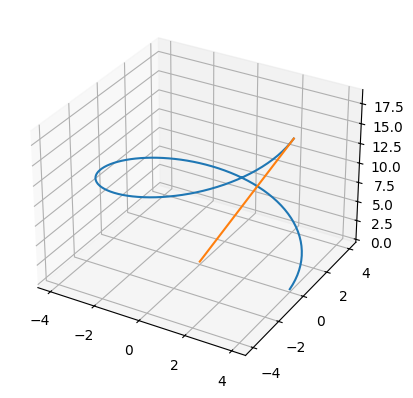

In [34]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot(xmarks,ymarks,zmarks) # Teken de helix
positieVector, = ax.plot([],[],[]) # Maak een object klaar voor de positievector

def animate(i): # De animatiefunctie
    positieVector.set_data([0,xmarks[i]],[0, ymarks[i]])
    positieVector.set_3d_properties([0, zmarks[i]])
    
anim = animation.FuncAnimation(fig, animate, frames=100, interval=50)
anim.save("helix.gif")
plt.show()

Het enige wezenlijk verschil met de code in 2D zit in de animatiefunctie. Als je in een 3D-plot de data wilt aanpassen in de animatiefunctie kan je met `set_data()` enkel aanpassingen maken in de $x$- en $y$-coördinaten. Voor de $z$-coördinaat moet je `set_3d_properties()` gebruiken.

## Het geanimeerde Frenetstelsel: deel 2

**Opdracht 5:** Nu is het tijd om het hele Frenetstelsel te animeren. De code voor de raakvector is gegeven. Werk zelf de code af voor de normaal en de binormaal.

**<font color="red">Opmerking</font>**: ook hier ga je moeten opletten dat de argumenten Numpy-arrays zijn indien je bij het vorige voorbeeld problemen had.

In [ ]:
Tx = sp.lambdify(s, hatT[0], "numpy")(ss)
Ty = sp.lambdify(s, hatT[1], "numpy")(ss)
Tz = np.vectorize(sp.lambdify(s, hatT[2], "numpy"))(ss)

# Vul hier de code aan






# --------------------

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot(xmarks,ymarks,zmarks)
T, = ax.plot([],[],[])
N, = ax.plot([],[],[])
B, = ax.plot([],[],[])

def animate(i):
    T.set_data([xmarks[i], xmarks[i] + Tx[i]],[ymarks[i], ymarks[i] + Ty[i]])
    T.set_3d_properties([zmarks[i], zmarks[i] + Tz[i]])
    
    # Vul hier de code aan
    
    
    
    
    
    
    # --------------------

anim = animation.FuncAnimation(fig, animate, frames=100, interval=50)
plt.show()

## Waarom lijnstukken in plaats van vectoren?

Je hebt misschien opgemerkt dat in de animaties we altijd lijnstukken hebben getekend waar we vectoren wouden animeren. Nochtans hebben we in het werkblad over differentiaalvergelijkingen richtingsvelden met échte vectoren (inclusief pijltjes) getekend. Kunnen we het commando dat we toen gebruikten (`quiver`) nu ook niet aan de slag gaan? 

Dit is mogelijk maar er is een reden waarom we met lijnstukken werken.. Het commando `quiver` dat vectoren (en vectorvelden) kan tekenen in 2D heeft een analoge werkwijze voor 3D maar de 3D-versie werkt niet goed samen met animaties. Iedere stap van de animatie moet immers de data van de plot aangepast worden en dit is lastig met de 3D-versie van `quiver`. In de plaats daarvan gaan we werken met gewone lijnstukken in plaats van vectoren. Deze lenen zich beter tot onze doelen.

## Je animaties bewaren

Je kan de animatie ook opslaan als videobestand. Hiervoor kan je onderstaande regel code uit comment halen. Let wel op: om dit commando te kunnen uitvoeren, moet je het programma ffmpeg op je computer geïnstalleerd hebben. Is dit niet het geval, dan zal python klagen. De functie `save` moet je enkel de naam meegeven van het videobestand en het aantal beelden per seconde dat je video nodig heeft.

In [ ]:
#anim.save('Frenetstelsel.mp4', fps=15)

Uiteraard is dit nog maar een begin wat betreft de animatiemogelijkheden. Als je een idee wilt hebben van wat er zoal mogelijk is, kan je eens kijken naar [volgende blogpost](https://jakevdp.github.io/blog/2013/02/16/animating-the-lorentz-system-in-3d/) waar iemand een stelsel van drie differentiaalvergelijkingen numeriek oplost met `scipy`, vervolgens voor twintig beginvoorwaarden de oplossingskrommen in $\mathbb{R}^3$ berekent en tot slot een animatie maakt van alle twintig paden.

## Het tracen van een grafiek

Nu gaan we een animatie maken waarin de grafiek van een functie gedeeltelijk wordt getekend. Stel dat we code hebben om de grafiek van de sinusfunctie te tekenen.

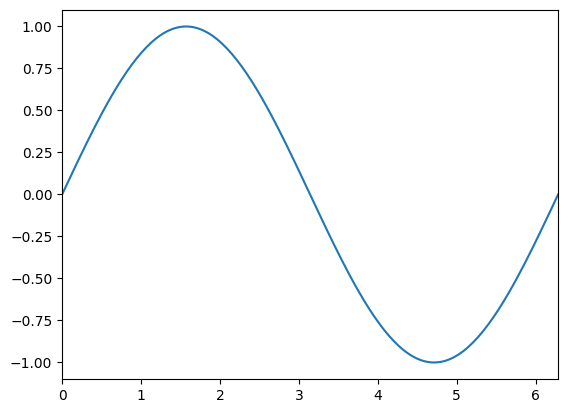

In [35]:
X = np.linspace(0, 2*np.pi, 200)
Y = np.sin(X)

fig, ax = plt.subplots(1,1)
ax.plot(X, Y)

ax.set_xlim([0, 2*np.pi])
ax.set_ylim([-1.1, 1.1])

plt.show()

Wat als we maar een deel van de grafiek willen tekenen? De lijsten `X` en `Y` bevatten elk 200 elementen. Als we enkel de eerste 50 willen tekenen kunnen we de volgende code gebruiken.

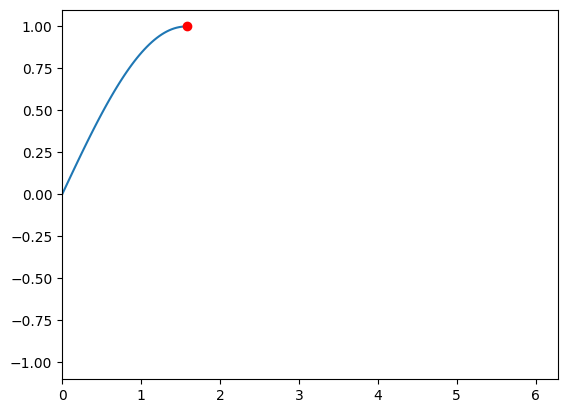

In [36]:
X = np.linspace(0, 2*np.pi, 200)
Y = np.sin(X)
i = 50

fig, ax = plt.subplots(1,1)
ax.plot(X[:i], Y[:i])
ax.plot(X[i], Y[i], 'o', color='red')

ax.set_xlim([0, 2*np.pi])
ax.set_ylim([-1.1, 1.1])

plt.show()

Je ziet dat we zo maar een kwart van de kromme getekend hebben. Dit komt doordat de code `X[:i]` de lijst `X` afkapt tot aan index `i`. Als je zelf de variabele `i` aanpast en de code opnieuw uitvoert, zal je een ander stuk van de kromme krijgen. Het tweede plotcommando tekent een rood bolletje op het eindpunt van de kromme.

**Opdracht 6:** Baseer je op bovenstaand principe om een animatie te maken waarbij het rode bolletje start in het punt $(0,0)$ en de hele sinuskromme tekent

In [ ]:
# Los hier de opdracht op

